In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
data=pd.read_csv(r"Feature Engineering/Social_Network_Ads.csv")
data.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [10]:
data.shape

(400, 5)

In [11]:
data=data.iloc[:,2:].copy()
data.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [12]:
data.isna().sum()

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data.drop(columns='Purchased'),
                                                    data[['Purchased']],
                                                    test_size=0.3,
                                                    random_state=0)
X_train.shape, X_test.shape

((280, 2), (120, 2))

In [18]:
from sklearn.preprocessing import StandardScaler

s=StandardScaler()
X_train_scale=s.fit_transform(X_train)
X_test_scale=s.transform(X_test)

In [21]:
s.mean_

array([3.78642857e+01, 6.98071429e+04])

In [22]:
X_train_scale = pd.DataFrame(X_train_scale, columns=X_train.columns)
X_test_scale = pd.DataFrame(X_test_scale, columns=X_test.columns)

In [24]:
np.round(X_train_scale.describe(),2)

,Age,EstimatedSalary
count,280.00,280.00
mean,0.00,0.00
std,1.00,1.00
min,-1.95,-1.58
25%,-0.77,-0.78
50%,-0.08,0.02
75%,0.80,0.53
max,2.17,2.32


In [25]:
# Effect of Scaling

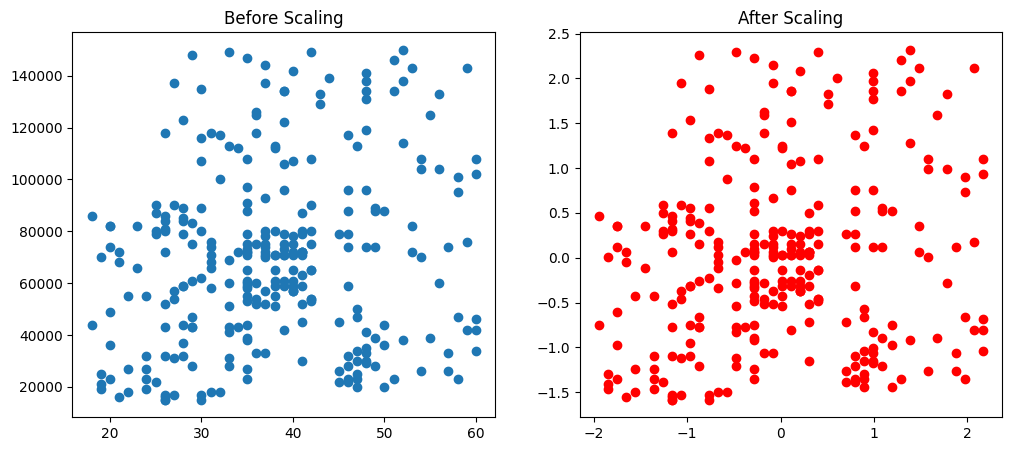

In [29]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scale['Age'], X_train_scale['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()

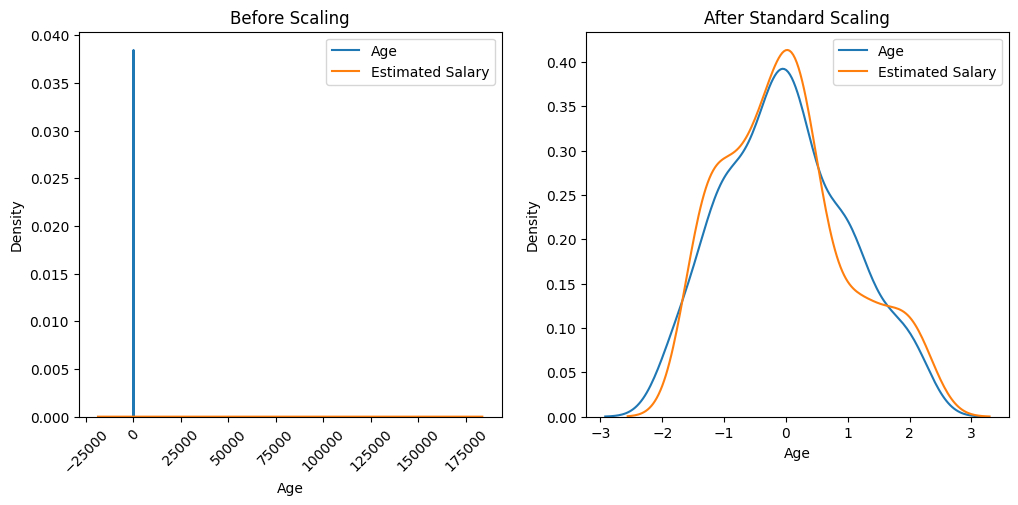

In [50]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
sns.kdeplot(X_train['Age'], ax=ax1,label='Age')
sns.kdeplot(X_train['EstimatedSalary'],label='Estimated Salary',ax=ax1)
ax1.set_title('Before Scaling')
ax1.legend()
ax1.tick_params(axis='x', rotation=45)

# after scaling
sns.kdeplot(X_train_scale['Age'], ax=ax2,label='Age')
sns.kdeplot(X_train_scale['EstimatedSalary'],label='Estimated Salary', ax=ax2)
ax2.set_title('After Standard Scaling')
ax2.legend()
plt.show()

In [51]:
# Comparison of Distributions

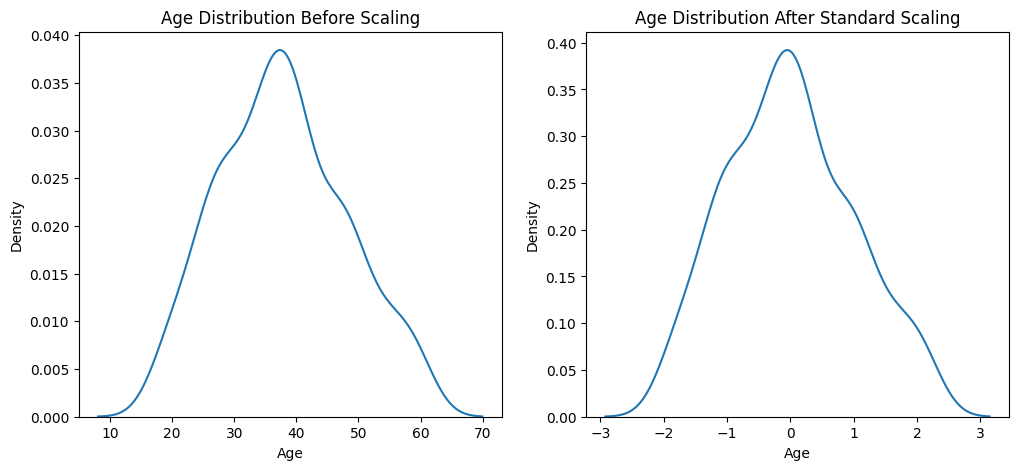

In [53]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Age Distribution Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)

# after scaling
ax2.set_title('Age Distribution After Standard Scaling')
sns.kdeplot(X_train_scale['Age'], ax=ax2)
plt.show()

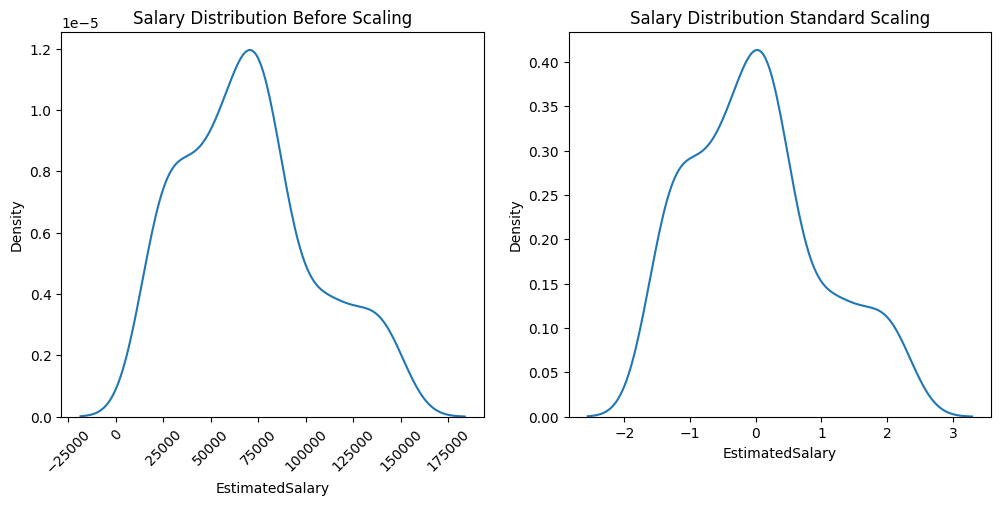

In [56]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Salary Distribution Before Scaling')
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)
ax1.tick_params(axis='x',rotation=45)

# after scaling
ax2.set_title('Salary Distribution Standard Scaling')
sns.kdeplot(X_train_scale['EstimatedSalary'], ax=ax2)
plt.show()

In [59]:
# why?

In [72]:
# with scaling -> LogisticRegression 

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr=LogisticRegression()
lr.fit(X_train_scale,y_train)

y_pred=lr.predict(X_test_scale)
score=accuracy_score(y_test,y_pred)
score

C:\Users\PRASHANT\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.8666666666666667

In [73]:
# without scaling -> LogisticRegression

lr1=LogisticRegression()
lr1.fit(X_train,y_train)

y_pred1=lr1.predict(X_test)
score1=accuracy_score(y_test,y_pred1)
score1

C:\Users\PRASHANT\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.875

In [74]:
# without scaling -> KNN

from sklearn.neighbors import KNeighborsClassifier

clf1=KNeighborsClassifier()
clf1.fit(X_train,y_train)

y_pred1=clf1.predict(X_test)
score1=accuracy_score(y_test,y_pred1)
score1

C:\Users\PRASHANT\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


0.825

In [71]:
# with scaling -> KNN

clf2=KNeighborsClassifier()
clf2.fit(X_train_scale,y_train)

y_pred1=clf2.predict(X_test_scale)
score1=accuracy_score(y_test,y_pred1)
score1

C:\Users\PRASHANT\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


0.9166666666666666

In [75]:
# Effect of Outliers

In [89]:
temp = pd.concat((data,pd.DataFrame({'Age':[5,90,95],'EstimatedSalary':[1000,250000,350000],'Purchased':[0,1,1]})),ignore_index=True,axis=0)

In [91]:
temp.tail(4)

,Age,EstimatedSalary,Purchased
399,49,36000,1
400,5,1000,0
401,90,250000,1
402,95,350000,1


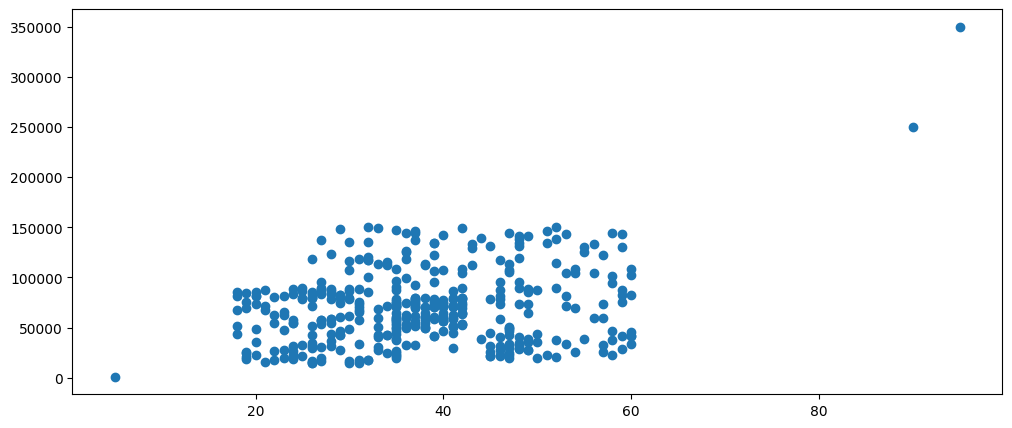

In [94]:
plt.figure(figsize=(12,5))
plt.scatter(temp['Age'], temp['EstimatedSalary'])
plt.show()

In [95]:
X_train, X_test, y_train, y_test = train_test_split(temp.drop('Purchased', axis=1),
                                                    temp['Purchased'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((282, 2), (121, 2))

In [96]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [97]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

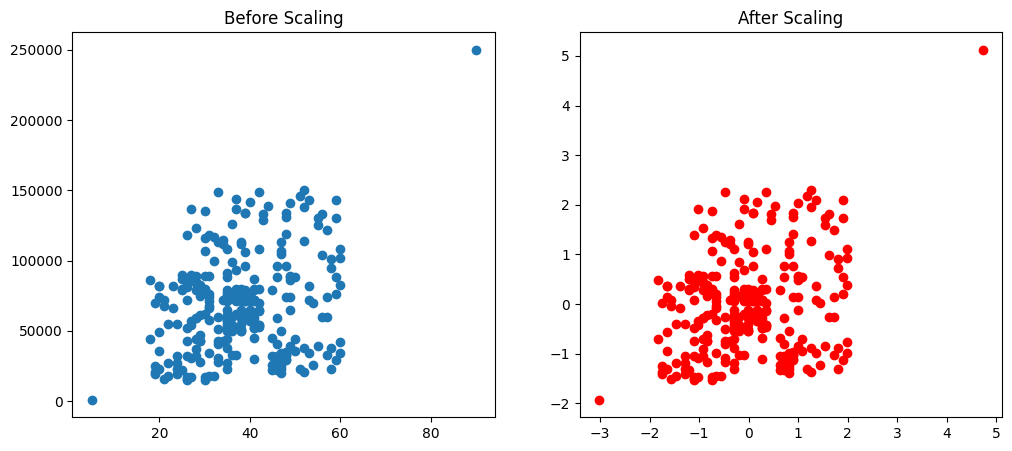

In [98]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()